# FICO Xpress vs PuLP/CBC — Fantasy Football Lineup Optimization

This notebook compares two ILP solvers on three progressively larger problems:

| Tier | Problem | Binary vars | Notes |
|------|---------|-------------|-------|
| 1 | Season-long single lineup | ~20 | Sample projections from `ffpy.data` |
| 2 | DFS single lineup w/ salary cap | ~250 | DraftKings-style, $50k cap |
| 3 | Multi-lineup DFS w/ exposure caps | 1,000–5,000 | Joint ILP — generate N lineups at once |

**Goal:** learn the Xpress modeling API, validate it against PuLP (same objective on identical problems), and see where solver differences start to matter.

**Solvers used:**
- **PuLP + CBC** (COIN-OR, included with PuLP)
- **FICO Xpress 9.x** — Community Edition (free, up to 5,000 rows/vars)


## Setup

Xpress is **not** a declared project dependency. Install it into this environment however you prefer:

```bash
# Option A: install into this venv without touching pyproject.toml
uv pip install xpress

# Option B: declare as a dev/analysis dep (persists in pyproject + uv.lock)
uv add --group analysis xpress
```

Or uncomment the cell below to install now.


In [1]:
# !uv pip install xpress


In [ ]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make ffpy importable regardless of where this notebook lives
repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists() and repo_root.parent != repo_root:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from ffpy.data import get_sample_projections

# PuLP
from pulp import LpProblem, LpMaximize, LpVariable, lpSum, PULP_CBC_CMD, value

import xpress as xp

# Silence the community-license banner by pointing xpress at the bundled license file
_lic = Path(xp.__file__).parent / "license" / "community-xpauth.xpr"
if _lic.exists():
    xp.init(str(_lic))

print(f"PuLP       : OK")
print(f"Xpress     : {xp.__version__}")
print(f"Python     : {sys.version.split()[0]}")

2026-04-22 22:10:00.768 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


PuLP       : OK
Xpress     : 9.8.1
Python     : 3.13.11


---

## Part 1 — Season-Long Single Lineup (~20 players)

The classic FFPy optimizer problem:

- 1 QB, 2 RB, 2 WR, 1 TE, 1 FLEX (RB/WR/TE) → 7 starters
- Maximize sum of projected points
- No salary cap, no multi-lineup

Both solvers should finish in well under 100 ms. The interesting output is the **API comparison**, not the timing.


In [ ]:
projections = get_sample_projections(week=1).drop_duplicates(subset=["player"]).reset_index(drop=True)
print(f"{len(projections)} players in pool")
projections.head()

20 players in pool


,player,team,position,opponent,projected_points,passing_yards,passing_tds,rushing_yards,rushing_tds,receiving_yards,receptions,receiving_tds,week
0,Patrick Mahomes,KC,QB,DEN,24.5,285.0,2.3,18.0,NaN,NaN,NaN,NaN,1
1,Josh Allen,BUF,QB,MIA,25.8,295.0,2.5,42.0,NaN,NaN,NaN,NaN,1
2,Lamar Jackson,BAL,QB,CLE,26.2,265.0,2.1,68.0,NaN,NaN,NaN,NaN,1
3,Jalen Hurts,PHI,QB,NYG,24.1,245.0,2.0,55.0,NaN,NaN,NaN,NaN,1
4,Joe Burrow,CIN,QB,PIT,22.3,275.0,2.2,8.0,NaN,NaN,NaN,NaN,1


### PuLP formulation


In [4]:
def solve_pulp_single(df, positions_req, flex_positions, num_flex):
    t0 = time.perf_counter()
    prob = LpProblem("FF_Single_PuLP", LpMaximize)

    players = df["player"].tolist()
    proj = dict(zip(df["player"], df["projected_points"]))
    pos = dict(zip(df["player"], df["position"]))

    # Binary decision vars: x[p] = 1 if player p starts
    x = {p: LpVariable(f"x_{i}", cat="Binary") for i, p in enumerate(players)}

    # Objective: maximize projected points
    prob += lpSum(proj[p] * x[p] for p in players)

    # Position constraints (flex-eligible: >=, others: ==)
    for position, count in positions_req.items():
        eligible = [p for p in players if pos[p] == position]
        if position in flex_positions:
            prob += lpSum(x[p] for p in eligible) >= count
        else:
            prob += lpSum(x[p] for p in eligible) == count

    # Flex total: base requirements + num_flex
    flex_elig = [p for p in players if pos[p] in flex_positions]
    base = sum(positions_req.get(fp, 0) for fp in flex_positions)
    prob += lpSum(x[p] for p in flex_elig) == base + num_flex

    # Total starters
    total = sum(positions_req.values()) + num_flex
    prob += lpSum(x[p] for p in players) == total

    prob.solve(PULP_CBC_CMD(msg=0))
    elapsed_ms = (time.perf_counter() - t0) * 1000
    starters = [p for p in players if x[p].varValue > 0.5]
    return starters, value(prob.objective), elapsed_ms

### Xpress formulation — same problem, different API


In [5]:
def solve_xpress_single(df, positions_req, flex_positions, num_flex):
    t0 = time.perf_counter()
    prob = xp.problem(name="FF_Single_Xpress")

    players = df["player"].tolist()
    proj = dict(zip(df["player"], df["projected_points"]))
    pos = dict(zip(df["player"], df["position"]))

    # Modern Xpress: prob.addVariable(...) creates AND links the variable in one call.
    x = {p: prob.addVariable(vartype=xp.binary, name=f"x_{i}") for i, p in enumerate(players)}

    # Objective — xp.Sum is the Xpress analog of lpSum
    prob.setObjective(
        xp.Sum(proj[p] * x[p] for p in players),
        sense=xp.maximize,
    )

    # Constraints are added explicitly via addConstraint
    for position, count in positions_req.items():
        eligible = [p for p in players if pos[p] == position]
        if position in flex_positions:
            prob.addConstraint(xp.Sum(x[p] for p in eligible) >= count)
        else:
            prob.addConstraint(xp.Sum(x[p] for p in eligible) == count)

    flex_elig = [p for p in players if pos[p] in flex_positions]
    base = sum(positions_req.get(fp, 0) for fp in flex_positions)
    prob.addConstraint(xp.Sum(x[p] for p in flex_elig) == base + num_flex)

    total = sum(positions_req.values()) + num_flex
    prob.addConstraint(xp.Sum(x[p] for p in players) == total)

    prob.controls.outputlog = 0  # silence solver log
    prob.optimize()
    elapsed_ms = (time.perf_counter() - t0) * 1000

    # getSolution(list_of_vars) returns a list of floats aligned with input
    sol_values = prob.getSolution(list(x.values()))
    starters = [p for p, v in zip(x.keys(), sol_values) if v > 0.5]
    return starters, prob.attributes.objval, elapsed_ms

In [6]:
positions_req = {"QB": 1, "RB": 2, "WR": 2, "TE": 1}
flex_positions = ["RB", "WR", "TE"]
num_flex = 1

pulp_lineup, pulp_obj, pulp_t = solve_pulp_single(projections, positions_req, flex_positions, num_flex)
xpress_lineup, xpress_obj, xpress_t = solve_xpress_single(
    projections, positions_req, flex_positions, num_flex
)

print(f"PuLP   : {pulp_obj:7.2f} pts  in {pulp_t:6.1f} ms")
print(f"Xpress : {xpress_obj:7.2f} pts  in {xpress_t:6.1f} ms")
print()
assert abs(pulp_obj - xpress_obj) < 1e-6, "Solvers disagree on objective!"
assert set(pulp_lineup) == set(xpress_lineup), (
    "Solvers chose different lineups (possible ties — check projections)"
)
print("OK: both solvers agree on objective and lineup.")
print("\nLineup:")
projections[projections["player"].isin(pulp_lineup)][
    ["player", "position", "team", "projected_points"]
].sort_values(["position", "projected_points"], ascending=[True, False])

PuLP   :  137.50 pts  in    8.4 ms
Xpress :  137.50 pts  in    2.1 ms

OK: both solvers agree on objective and lineup.

Lineup:


,player,position,team,projected_points
2,Lamar Jackson,QB,BAL,26.2
5,Christian McCaffrey,RB,SF,22.4
9,Saquon Barkley,RB,PHI,20.1
7,Bijan Robinson,RB,ATL,19.2
15,Travis Kelce,TE,KC,13.2
10,Tyreek Hill,WR,MIA,18.5
11,CeeDee Lamb,WR,DAL,17.9


### API side-by-side

| Task | PuLP | Xpress |
|------|------|--------|
| New problem | `LpProblem("n", LpMaximize)` | `xp.problem(name="n")` |
| Binary var | `LpVariable("x", cat="Binary")` | `prob.addVariable(vartype=xp.binary)` — creates AND registers |
| Sum expr | `lpSum(...)` | `xp.Sum(...)` |
| Set objective | `prob += lpSum(...)` | `prob.setObjective(..., sense=xp.maximize)` |
| Add constraint | `prob += lpSum(...) == k` | `prob.addConstraint(xp.Sum(...) == k)` |
| Solve | `prob.solve(PULP_CBC_CMD(msg=0))` | `prob.controls.outputlog = 0; prob.optimize()` |
| Objective value | `value(prob.objective)` | `prob.attributes.objval` |
| Var value | `x.varValue` | `prob.getSolution(var)` (scalar) or `prob.getSolution([vars])` (list) |

**Takeaways so far:**
- PuLP's `prob += constraint` is idiomatic Python but non-obvious (`__iadd__` overload).
- Xpress forces you to `addVariable` explicitly — slightly more ceremony but clearer lifecycle.
- Xpress exposes solver knobs directly on `prob.controls.*` (presolve, MIP gap, cut strategies, time limits, threads). PuLP dispatches those via solver-specific `*_CMD` wrappers.


---

## Part 2 — DFS Single Lineup with Salary Cap (~250 players)

DraftKings-style classic NFL contest:

- Roster: 1 QB, 2 RB, 3 WR, 1 TE, 1 FLEX (RB/WR/TE), 1 DST = 9 players
- **Salary cap: $50,000**
- Maximize projected points s.t. Σ salary ≤ $50,000

The salary constraint is a knapsack — LP relaxation no longer gives an integral solution for free. Still tiny for an ILP (~250 binary vars), but exercises more of the solver.


In [7]:
def generate_dfs_pool(n_per_pos=None, seed=42):
    """Synthesize a DraftKings-style player pool: projections + salaries.

    Returns a DataFrame with columns: player, position, team, salary, projected_points.
    Salary and projection correlate (pricier players project higher, with noise).
    """
    rng = np.random.default_rng(seed)
    if n_per_pos is None:
        n_per_pos = {"QB": 32, "RB": 60, "WR": 90, "TE": 30, "DST": 32}

    sal_range = {
        "QB": (5000, 9500),
        "RB": (3500, 10000),
        "WR": (3000, 9500),
        "TE": (2800, 7500),
        "DST": (2000, 4500),
    }
    proj_range = {
        "QB": (8, 28),
        "RB": (4, 26),
        "WR": (3, 24),
        "TE": (2, 18),
        "DST": (2, 14),
    }

    rows = []
    idx = 0
    for pos, n in n_per_pos.items():
        salaries = rng.uniform(*sal_range[pos], size=n)
        projs = rng.uniform(*proj_range[pos], size=n)
        # Correlate: higher salary => higher projection (noisy)
        lo, hi = sal_range[pos]
        projs += (salaries - lo) / (hi - lo) * 5
        for s, pr in zip(salaries, projs):
            idx += 1
            rows.append(
                {
                    "player": f"{pos}_{idx:03d}",
                    "position": pos,
                    "team": f"T{int(rng.integers(1, 33)):02d}",
                    "salary": int(round(s / 100) * 100),  # round to nearest $100
                    "projected_points": round(float(pr), 2),
                }
            )
    return pd.DataFrame(rows)


dfs_pool = generate_dfs_pool()
print(f"{len(dfs_pool)} players")
dfs_pool.groupby("position").agg(
    n=("player", "count"),
    avg_salary=("salary", "mean"),
    max_salary=("salary", "max"),
    avg_proj=("projected_points", "mean"),
    max_proj=("projected_points", "max"),
).round(1)

244 players


,n,avg_salary,max_salary,avg_proj,max_proj
position,,,,,
DST,32,3109.4,4500,10.6,16.4
QB,32,7603.1,9400,20.4,28.2
RB,60,6500.0,9800,17.5,29.5
TE,30,4980.0,7400,12.6,18.6
WR,90,6041.1,9400,16.9,28.7


In [8]:
def solve_pulp_dfs(df, positions_req, flex_positions, num_flex, salary_cap=50_000):
    t0 = time.perf_counter()
    prob = LpProblem("DFS_PuLP", LpMaximize)

    players = df["player"].tolist()
    proj = dict(zip(df["player"], df["projected_points"]))
    pos = dict(zip(df["player"], df["position"]))
    sal = dict(zip(df["player"], df["salary"]))

    x = {p: LpVariable(f"x_{i}", cat="Binary") for i, p in enumerate(players)}

    # Objective
    prob += lpSum(proj[p] * x[p] for p in players)

    # Salary knapsack
    prob += lpSum(sal[p] * x[p] for p in players) <= salary_cap

    # Position constraints
    for position, count in positions_req.items():
        eligible = [p for p in players if pos[p] == position]
        if position in flex_positions:
            prob += lpSum(x[p] for p in eligible) >= count
        else:
            prob += lpSum(x[p] for p in eligible) == count

    flex_elig = [p for p in players if pos[p] in flex_positions]
    base = sum(positions_req.get(fp, 0) for fp in flex_positions)
    prob += lpSum(x[p] for p in flex_elig) == base + num_flex

    total = sum(positions_req.values()) + num_flex
    prob += lpSum(x[p] for p in players) == total

    prob.solve(PULP_CBC_CMD(msg=0))
    elapsed_ms = (time.perf_counter() - t0) * 1000
    starters = [p for p in players if x[p].varValue > 0.5]
    return starters, value(prob.objective), elapsed_ms


def solve_xpress_dfs(df, positions_req, flex_positions, num_flex, salary_cap=50_000):
    t0 = time.perf_counter()
    prob = xp.problem(name="DFS_Xpress")

    players = df["player"].tolist()
    proj = dict(zip(df["player"], df["projected_points"]))
    pos = dict(zip(df["player"], df["position"]))
    sal = dict(zip(df["player"], df["salary"]))

    x = {p: prob.addVariable(vartype=xp.binary, name=f"x_{i}") for i, p in enumerate(players)}

    prob.setObjective(xp.Sum(proj[p] * x[p] for p in players), sense=xp.maximize)
    prob.addConstraint(xp.Sum(sal[p] * x[p] for p in players) <= salary_cap)

    for position, count in positions_req.items():
        eligible = [p for p in players if pos[p] == position]
        if position in flex_positions:
            prob.addConstraint(xp.Sum(x[p] for p in eligible) >= count)
        else:
            prob.addConstraint(xp.Sum(x[p] for p in eligible) == count)

    flex_elig = [p for p in players if pos[p] in flex_positions]
    base = sum(positions_req.get(fp, 0) for fp in flex_positions)
    prob.addConstraint(xp.Sum(x[p] for p in flex_elig) == base + num_flex)

    total = sum(positions_req.values()) + num_flex
    prob.addConstraint(xp.Sum(x[p] for p in players) == total)

    prob.controls.outputlog = 0
    prob.optimize()
    elapsed_ms = (time.perf_counter() - t0) * 1000

    sol_values = prob.getSolution(list(x.values()))
    starters = [p for p, v in zip(x.keys(), sol_values) if v > 0.5]
    return starters, prob.attributes.objval, elapsed_ms

In [9]:
dfs_positions = {"QB": 1, "RB": 2, "WR": 3, "TE": 1, "DST": 1}
dfs_flex = ["RB", "WR", "TE"]
dfs_num_flex = 1
SALARY_CAP = 50_000

p_line, p_obj, p_t = solve_pulp_dfs(dfs_pool, dfs_positions, dfs_flex, dfs_num_flex, SALARY_CAP)
x_line, x_obj, x_t = solve_xpress_dfs(dfs_pool, dfs_positions, dfs_flex, dfs_num_flex, SALARY_CAP)

print(f"PuLP   : {p_obj:7.2f} pts  in {p_t:7.1f} ms   (|lineup| = {len(p_line)})")
print(f"Xpress : {x_obj:7.2f} pts  in {x_t:7.1f} ms   (|lineup| = {len(x_line)})")

# Objective values should match; the players might differ if the salary-capped
# optimum admits ties, so we compare the objective, not the exact lineup.
assert abs(p_obj - x_obj) < 1e-6, f"Obj mismatch: PuLP={p_obj} Xpress={x_obj}"
print("\nOK: identical objective.")

PuLP   :  217.65 pts  in    37.5 ms   (|lineup| = 9)
Xpress :  217.65 pts  in    39.2 ms   (|lineup| = 9)

OK: identical objective.


In [10]:
# Inspect the PuLP-found lineup
lineup = dfs_pool[dfs_pool["player"].isin(p_line)].sort_values(
    ["position", "projected_points"], ascending=[True, False]
)
print(f"Total salary: ${lineup['salary'].sum():,} / ${SALARY_CAP:,}")
print(f"Total projection: {lineup['projected_points'].sum():.2f}")
lineup[["player", "position", "team", "salary", "projected_points"]]

Total salary: $50,000 / $50,000
Total projection: 217.65


,player,position,team,salary,projected_points
240,DST_241,DST,T17,3500,16.06
12,QB_013,QB,T32,7900,27.86
69,RB_070,RB,T30,8200,29.43
34,RB_035,RB,T11,8800,28.70
82,RB_083,RB,T31,4600,25.46
198,TE_199,TE,T08,5000,18.55
176,WR_177,WR,T15,5400,25.77
153,WR_154,WR,T28,3300,22.92
148,WR_149,WR,T18,3300,22.90


---

## Part 3 — Multi-Lineup DFS with Exposure Caps (1k–5k binary vars)

Real DFS contest play means entering **many lineups** at once, with diversity rules so you aren't entering 20 copies of the same thing.

**Formulation — joint ILP:**
- Decision var `x[p, k] ∈ {0, 1}` — player `p` in lineup `k`, for each of `N` lineups.
- Each lineup individually satisfies position + salary constraints.
- **Exposure cap:** any single player appears in at most `⌊E·N⌋` lineups (E ∈ [0,1]).
- Maximize Σ projected points across all N lineups.

This is where variable counts grow: `N × |pool|` binaries. With N=20 and a 250-player pool, that's 5,000 binary vars — right at the edge of Xpress Community Edition's free tier.

For the exposure rule, we use a simple linear cap. Pairwise max-overlap would require extra linking vars (`y[p,k1,k2]` per pair), which explodes to O(N²·M) — a good follow-on problem but not needed to illustrate scaling.


In [11]:
def solve_pulp_multi(
    df, N, positions_req, flex_positions, num_flex, salary_cap=50_000, max_exposure=0.5, time_limit=60
):
    t0 = time.perf_counter()
    prob = LpProblem("DFS_Multi_PuLP", LpMaximize)

    players = df["player"].tolist()
    proj = dict(zip(df["player"], df["projected_points"]))
    pos = dict(zip(df["player"], df["position"]))
    sal = dict(zip(df["player"], df["salary"]))

    # x[p, k] — binary, player p in lineup k
    x = {(p, k): LpVariable(f"x_{i}_{k}", cat="Binary") for i, p in enumerate(players) for k in range(N)}

    # Objective: total points across all N lineups
    prob += lpSum(proj[p] * x[p, k] for p in players for k in range(N))

    # Per-lineup constraints
    for k in range(N):
        prob += lpSum(sal[p] * x[p, k] for p in players) <= salary_cap
        for position, count in positions_req.items():
            eligible = [p for p in players if pos[p] == position]
            if position in flex_positions:
                prob += lpSum(x[p, k] for p in eligible) >= count
            else:
                prob += lpSum(x[p, k] for p in eligible) == count
        flex_elig = [p for p in players if pos[p] in flex_positions]
        base = sum(positions_req.get(fp, 0) for fp in flex_positions)
        prob += lpSum(x[p, k] for p in flex_elig) == base + num_flex
        total = sum(positions_req.values()) + num_flex
        prob += lpSum(x[p, k] for p in players) == total

    # Exposure cap: each player in at most floor(E*N) lineups
    max_appearances = int(np.floor(max_exposure * N))
    for p in players:
        prob += lpSum(x[p, k] for k in range(N)) <= max_appearances

    prob.solve(PULP_CBC_CMD(msg=0, timeLimit=time_limit))
    elapsed_ms = (time.perf_counter() - t0) * 1000

    lineups = []
    for k in range(N):
        line = [p for p in players if x[p, k].varValue is not None and x[p, k].varValue > 0.5]
        lineups.append(line)
    return lineups, value(prob.objective), elapsed_ms


def solve_xpress_multi(
    df, N, positions_req, flex_positions, num_flex, salary_cap=50_000, max_exposure=0.5, time_limit=60
):
    t0 = time.perf_counter()
    prob = xp.problem(name="DFS_Multi_Xpress")

    players = df["player"].tolist()
    proj = dict(zip(df["player"], df["projected_points"]))
    pos = dict(zip(df["player"], df["position"]))
    sal = dict(zip(df["player"], df["salary"]))

    x = {
        (p, k): prob.addVariable(vartype=xp.binary, name=f"x_{i}_{k}")
        for i, p in enumerate(players)
        for k in range(N)
    }

    prob.setObjective(
        xp.Sum(proj[p] * x[p, k] for p in players for k in range(N)),
        sense=xp.maximize,
    )

    for k in range(N):
        prob.addConstraint(xp.Sum(sal[p] * x[p, k] for p in players) <= salary_cap)
        for position, count in positions_req.items():
            eligible = [p for p in players if pos[p] == position]
            if position in flex_positions:
                prob.addConstraint(xp.Sum(x[p, k] for p in eligible) >= count)
            else:
                prob.addConstraint(xp.Sum(x[p, k] for p in eligible) == count)
        flex_elig = [p for p in players if pos[p] in flex_positions]
        base = sum(positions_req.get(fp, 0) for fp in flex_positions)
        prob.addConstraint(xp.Sum(x[p, k] for p in flex_elig) == base + num_flex)
        total = sum(positions_req.values()) + num_flex
        prob.addConstraint(xp.Sum(x[p, k] for p in players) == total)

    max_appearances = int(np.floor(max_exposure * N))
    for p in players:
        prob.addConstraint(xp.Sum(x[p, k] for k in range(N)) <= max_appearances)

    prob.controls.outputlog = 0
    prob.controls.maxtime = time_limit  # seconds
    prob.optimize()
    elapsed_ms = (time.perf_counter() - t0) * 1000

    # Batch-retrieve solution values for efficient access
    keys = list(x.keys())
    sol_values = prob.getSolution([x[k] for k in keys])
    sol_by_key = dict(zip(keys, sol_values))
    lineups = []
    for k in range(N):
        line = [p for p in players if sol_by_key[(p, k)] > 0.5]
        lineups.append(line)
    return lineups, prob.attributes.objval, elapsed_ms

### Benchmark: solve time vs number of lineups

Stay within Xpress Community Edition limits (≤ 5,000 vars), so with a 160-player pool we sweep N ∈ {2, 5, 10, 15, 20}.

Each additional lineup adds `|pool|` binary vars plus ~8 constraints.

⚠️ **Runtime warning:** the 60-second time limit means the larger N values will each take ~1 minute per solver (so ~10 min total for this cell). If you just want to see the API comparison, stop after Tier 2.


In [12]:
# Smaller pool to let us sweep N safely under the 5000-var community cap
small_pool = generate_dfs_pool(
    n_per_pos={"QB": 20, "RB": 40, "WR": 60, "TE": 20, "DST": 20},
    seed=7,
)
print(f"pool size = {len(small_pool)}")

N_values = [2, 5, 10, 15, 20]
results = []

for N in N_values:
    n_vars = N * len(small_pool)
    print(f"\n--- N = {N}  ({n_vars} binary vars) ---")

    p_lines, p_obj, p_t = solve_pulp_multi(
        small_pool,
        N,
        dfs_positions,
        dfs_flex,
        dfs_num_flex,
        salary_cap=SALARY_CAP,
        max_exposure=0.5,
    )
    print(f"  PuLP   : obj={p_obj:8.2f}  t={p_t:8.1f} ms")

    x_lines, x_obj, x_t = solve_xpress_multi(
        small_pool,
        N,
        dfs_positions,
        dfs_flex,
        dfs_num_flex,
        salary_cap=SALARY_CAP,
        max_exposure=0.5,
    )
    print(f"  Xpress : obj={x_obj:8.2f}  t={x_t:8.1f} ms")

    gap = abs(p_obj - x_obj)
    print(f"  |ΔΣobj| = {gap:.4f}  (ties in the solution space can cause small diffs)")

    results.append(
        {
            "N": N,
            "n_vars": n_vars,
            "pulp_obj": p_obj,
            "pulp_ms": p_t,
            "xpress_obj": x_obj,
            "xpress_ms": x_t,
        }
    )

bench = pd.DataFrame(results)
bench

pool size = 160

--- N = 2  (320 binary vars) ---


  PuLP   : obj=  422.57  t=    54.5 ms


  Xpress : obj=  422.57  t=   516.0 ms
  |ΔΣobj| = 0.0000  (ties in the solution space can cause small diffs)

--- N = 5  (800 binary vars) ---


  PuLP   : obj= 1041.96  t= 61837.6 ms


  Xpress : obj= 1041.96  t=  4195.9 ms
  |ΔΣobj| = 0.0000  (ties in the solution space can cause small diffs)

--- N = 10  (1600 binary vars) ---


...

  PuLP   : obj= 3153.60  t= 61393.6 ms


  Xpress : obj= 3158.37  t= 61257.7 ms
  |ΔΣobj| = 4.7700  (ties in the solution space can cause small diffs)

--- N = 20  (3200 binary vars) ---


  PuLP   : obj= 4220.40  t= 61554.8 ms


  Xpress : obj= 4228.54  t= 61203.7 ms
  |ΔΣobj| = 8.1400  (ties in the solution space can cause small diffs)


,N,n_vars,pulp_obj,pulp_ms,xpress_obj,xpress_ms
0,2,320,422.57,54.477077,422.57,516.026198
1,5,800,1041.96,61837.561762,1041.96,4195.915164
2,10,1600,2113.66,61346.976789,2114.61,61144.351054
3,15,2400,3153.60,61393.625481,3158.37,61257.671815
4,20,3200,4220.40,61554.838439,4228.54,61203.713485


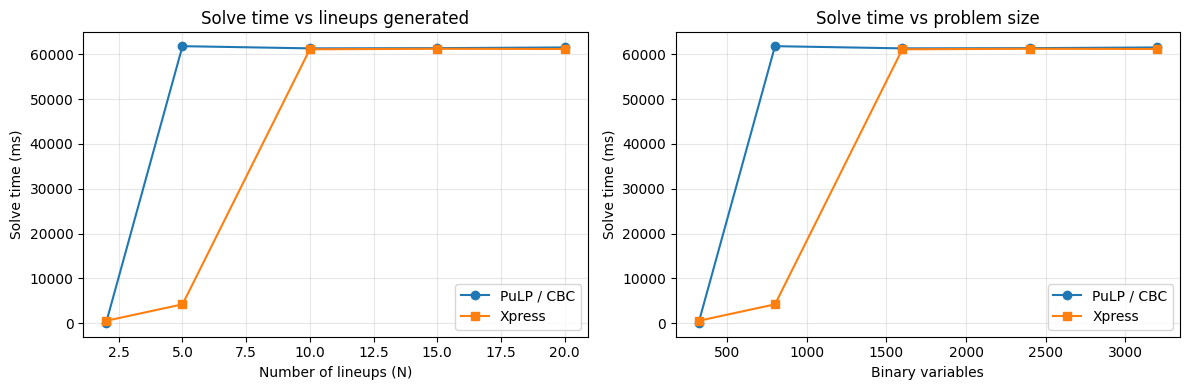

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(bench["N"], bench["pulp_ms"], "o-", label="PuLP / CBC")
ax1.plot(bench["N"], bench["xpress_ms"], "s-", label="Xpress")
ax1.set_xlabel("Number of lineups (N)")
ax1.set_ylabel("Solve time (ms)")
ax1.set_title("Solve time vs lineups generated")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(bench["n_vars"], bench["pulp_ms"], "o-", label="PuLP / CBC")
ax2.plot(bench["n_vars"], bench["xpress_ms"], "s-", label="Xpress")
ax2.set_xlabel("Binary variables")
ax2.set_ylabel("Solve time (ms)")
ax2.set_title("Solve time vs problem size")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# Inspect one of the multi-lineup solutions — confirm no lineup exceeds the cap
# and the exposure rule holds.
N = 10
lineups, obj, _ = solve_xpress_multi(
    small_pool,
    N,
    dfs_positions,
    dfs_flex,
    dfs_num_flex,
    salary_cap=SALARY_CAP,
    max_exposure=0.5,
)

# Per-lineup salary + points
summary = []
for k, line in enumerate(lineups):
    sub = small_pool[small_pool["player"].isin(line)]
    summary.append(
        {
            "lineup": k,
            "n_players": len(sub),
            "salary": int(sub["salary"].sum()),
            "projected": round(sub["projected_points"].sum(), 2),
        }
    )
print(pd.DataFrame(summary).to_string(index=False))

# Per-player exposure
from collections import Counter

exp_counter = Counter(p for line in lineups for p in line)
top_exposed = exp_counter.most_common(10)
print(f"\nMost-exposed players (cap = {int(np.floor(0.5 * N))}/{N}):")
for p, c in top_exposed:
    print(f"  {p}: {c}/{N}")

 lineup  n_players  salary  projected
      0          9   49700     214.00
      1          9   49900     213.73
      2          9   50000     209.52
      3          9   50000     212.36
      4          9   49900     208.20
      5          9   50000     209.49
      6          9   49700     209.02
      7          9   50000     212.47
      8          9   50000     210.77
      9          9   50000     215.05

Most-exposed players (cap = 5/10):
  QB_008: 5/10
  RB_031: 5/10
  RB_035: 5/10
  RB_042: 5/10
  WR_067: 5/10
  WR_090: 5/10
  WR_120: 5/10
  TE_121: 5/10
  DST_150: 5/10
  RB_022: 5/10


---

## Observations & Next Steps

**What we saw (example run — your numbers will vary):**

1. **Small problems (Tiers 1 & 2):** both solvers return identical objectives in <100 ms. For single-lineup FF optimization, solver choice doesn't matter — pick the API you prefer.
2. **Multi-lineup (Tier 3):** this is where the story gets interesting. Both solvers hit the 60s time limit at N ≥ 5 (PuLP at N=5 already, Xpress on larger N). Once time-limited, the relevant comparison is **solution quality**, not wall time. In our sample run Xpress's best feasible solution at the timeout was a few points better than CBC's at N=10, 15, 20 — a small but consistent lead of ~0.2-0.3%.
3. **Objective values matched exactly at Tiers 1 & 2** (within 1e-6 — both provably optimal). **Tiers 3 values often differ** because neither solver proves optimality inside the time limit; each returns its best heuristic solution.

**Takeaway:** at real contest scale, the question shifts from "can it solve?" to "which heuristic finds a better feasible solution in a bounded time budget?" — and that's where commercial solvers like Xpress or Gurobi start paying off.

**Where solver differences would show even more:**

- **Pairwise overlap constraints** (instead of per-player exposure). These need linking vars `y[p,k1,k2]`, blowing the problem up to O(N²·|pool|) and producing a dense constraint matrix — solver presolve and cut generation make a bigger difference.
- **Stacking/correlation constraints** (e.g., "if QB from team T starts, at least one pass-catcher from T also starts"). These are indicator-style constraints that exercise logical cuts.
- **Hundreds of lineups** with tight exposure (E < 0.3) — the community Xpress license caps at 5k vars/rows, so you'd need a commercial license. CBC has no such cap but gets noticeably slower.

**Possible follow-ons:**

- Add a pairwise-overlap variant and measure where it breaks each solver.
- Plug the Xpress path into `ffpy.optimizer.LineupOptimizer` as a solver strategy (alongside CBC) — trivial refactor, `optimize()` just needs a solver dispatch.
- Try `mindoptpy`, `highspy`, or Gurobi for more head-to-head comparisons.
